<a href="https://colab.research.google.com/github/MaeSantos/CCDEPLRL/blob/main/Before_After_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Before and After Model Optimization

This notebook compares an **unoptimized model** vs an **optimized model** using our Dog Classification dataset.

---

## Step 1: Mount Google Drive


In [66]:
from google.colab import drive
drive.mount('/content/drive')

import os

GDRIVE_PATH = '/content/drive/MyDrive/Dog_Emotions'

print('Google Drive mounted successfully!')
print('Drive contents:')
for item in os.listdir(GDRIVE_PATH):
    print(' -', item)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully!
Drive contents:
 - Happy
 - Sad
 - Angry


## Step 2: Install & Import Libraries

In [67]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# For reproducible results
tf.random.set_seed(42)
np.random.seed(42)

print('TensorFlow version:', tf.__version__)
print('GPU Available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Step 3: Load Dataset


In [68]:

# -------------------------------------------------------
# OPTION B: Load from Google Drive
# -------------------------------------------------------
import numpy as np
import os
import tensorflow as tf

# Define image dimensions and batch size
IMG_HEIGHT = 28
IMG_WIDTH = 28
BATCH_SIZE = 32

dataset = tf.keras.utils.image_dataset_from_directory(
    GDRIVE_PATH,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

class_names = dataset.class_names
print(f"Class names: {class_names}")

# Split the dataset into training, validation, and test sets
dataset_size = tf.data.experimental.cardinality(dataset).numpy() * BATCH_SIZE
# Use approximately 80% for training, 10% for validation, 10% for testing
train_size = int(0.8 * dataset_size)
val_size = int(0.1 * dataset_size)
test_size = dataset_size - train_size - val_size

# Shuffle and take samples
dataset = dataset.unbatch().shuffle(buffer_size=dataset_size, seed=42)

train_ds = dataset.take(train_size).batch(BATCH_SIZE)
val_ds = dataset.skip(train_size).take(val_size).batch(BATCH_SIZE)
test_ds = dataset.skip(train_size + val_size).take(test_size).batch(BATCH_SIZE)


# Convert TensorFlow datasets to NumPy arrays for compatibility with subsequent code
def datasets_to_numpy(tf_dataset):
    images_list = []
    labels_list = []
    for images, labels in tf_dataset:
        images_list.append(images.numpy())
        labels_list.append(labels.numpy())
    x = np.concatenate(images_list)
    y = np.concatenate(labels_list)
    return x, y

x_train_full, y_train_full = datasets_to_numpy(train_ds)
x_val_full, y_val_full = datasets_to_numpy(val_ds)
x_test_full, y_test_full = datasets_to_numpy(test_ds)

# Normalize pixel values from 0–255 to 0–1 and convert to float32
x_train_full = x_train_full.astype('float32') / 255.0
x_val_full = x_val_full.astype('float32') / 255.0
x_test_full = x_test_full.astype('float32') / 255.0

x_train, y_train = x_train_full, y_train_full # Full training data
x_test,  y_test  = x_test_full,  y_test_full  # Full test data

# Use a smaller subset for faster demo for the 'small' variables
x_train_small = x_train[:5000] if len(x_train) > 5000 else x_train
y_train_small = y_train[:5000] if len(y_train) > 5000 else y_train
x_val = x_val_full[:2000] if len(x_val_full) > 2000 else x_val_full
y_val = y_val_full[:2000] if len(y_val_full) > 2000 else y_val_full

print('Dataset loaded and preprocessed!')
print('Training data shape  :', x_train_small.shape)
print('Validation data shape:', x_val.shape)
print('Test data shape      :', x_test.shape)
print(f'Number of classes: {len(class_names)}')


Found 313 files belonging to 3 classes.
Class names: ['Angry', 'Happy', 'Sad']
Dataset loaded and preprocessed!
Training data shape  : (256, 28, 28, 3)
Validation data shape: (32, 28, 28, 3)
Test data shape      : (25, 28, 28, 3)
Number of classes: 3


## Step 4: Preview Sample Images

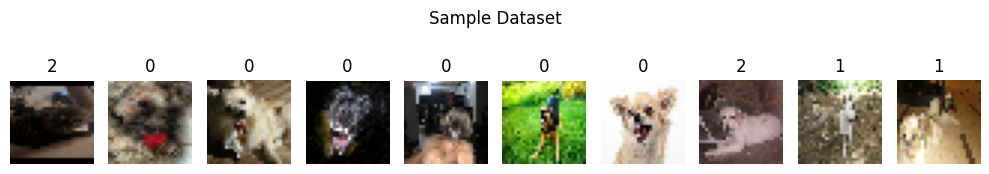

In [69]:
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train_small[i], cmap='gray')
    plt.title(str(y_train_small[i]))
    plt.axis('off')
plt.suptitle('Sample Dataset', fontsize=12)
plt.tight_layout()
plt.show()

---
## Step 5: BEFORE Model — Poorly Optimized

| Feature | Value |
|---|---|
| Optimizer | SGD |
| Learning Rate | 0.0001 (very slow) |
| Hidden Layers | 1 (only 16 neurons) |

In [70]:
before_model = models.Sequential([
    layers.Input(shape=(28, 28, 3)), # Changed input shape to include 3 color channels
    layers.Flatten(),
    layers.Dense(16, activation='relu'),
    layers.Dense(len(class_names), activation='softmax') # Corrected output layer to match the number of classes
], name='Before_Model')

before_model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

before_model.summary()

Model: "Before_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_10 (Flatten)            │ (None, 2352)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 16)             │        37,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,699 (147.26 KB)

 Trainable params: 37,699 (147.26 KB)

 Non-trainable params: 0 (0.00 B)

In [71]:
print('Training BEFORE model...\n')
before_history = before_model.fit(
    x_train_small,
    y_train_small,
    epochs=10,
    batch_size=32,
    validation_data=(x_val, y_val),
    verbose=1
)
print('\nBEFORE model training complete!')

Training BEFORE model...

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.3242 - loss: 1.2437 - val_accuracy: 0.3125 - val_loss: 1.2681
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3281 - loss: 1.2163 - val_accuracy: 0.3125 - val_loss: 1.2443
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3281 - loss: 1.1954 - val_accuracy: 0.3125 - val_loss: 1.2259
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3477 - loss: 1.1795 - val_accuracy: 0.3125 - val_loss: 1.2107
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3398 - loss: 1.1673 - val_accuracy: 0.3125 - val_loss: 1.1986
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3438 - loss: 1.1580 - val_accuracy: 0.2812 - val_loss: 1.1889
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3398 - loss: 1.1509 - val_accuracy: 0.2812 - val_loss: 1.1812
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3398 - loss: 1.1452 - val_accuracy: 

---
## Step 6: AFTER Model — Better Optimized

| Feature | Value |
|---|---|
| Optimizer | Adam |
| Learning Rate | 0.001 |
| Hidden Layers | 2 (128 → 64 neurons) |

In [72]:
after_model = models.Sequential([
    layers.Input(shape=(28, 28, 3)), # Corrected input shape to include 3 color channels
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64,  activation='relu'),
    layers.Dense(len(class_names),  activation='softmax') # Also corrected output layer to match number of classes
], name='After_Model')

after_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

after_model.summary()

Model: "After_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_11 (Flatten)            │ (None, 2352)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 128)            │       301,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 309,635 (1.18 MB)

 Trainable params: 309,635 (1.18 MB)

 Non-trainable params: 0 (0.00 B)

In [73]:
print('Training AFTER model...\n')
after_history = after_model.fit(
    x_train_small,
    y_train_small,
    epochs=10,
    batch_size=32,
    validation_data=(x_val, y_val),
    verbose=1
)
print('\nAFTER model training complete!')

Training AFTER model...

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.3477 - loss: 1.2466 - val_accuracy: 0.3750 - val_loss: 1.2316
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3672 - loss: 1.1445 - val_accuracy: 0.4375 - val_loss: 1.1427
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3984 - loss: 1.1649 - val_accuracy: 0.5000 - val_loss: 1.0570
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3906 - loss: 1.0838 - val_accuracy: 0.4062 - val_loss: 1.1027
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4258 - loss: 1.0810 - val_accuracy: 0.3438 - val_loss: 1.0930
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4180 - loss: 1.0622 - val_accuracy: 0.6562 - val_loss: 0.9792
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5742 - loss: 0.9639 - val_accuracy: 0.6875 - val_loss: 0.9473
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6328 - loss: 0.9346 - val_accuracy: 0

---
## Step 7: Evaluate Both Models on Test Set

In [74]:
before_test_loss, before_test_acc = before_model.evaluate(x_test, y_test, verbose=0)
after_test_loss,  after_test_acc  = after_model.evaluate(x_test,  y_test, verbose=0)

print('\n================ RESULTS ================')
print(f'BEFORE Model — Test Loss: {before_test_loss:.4f} | Test Accuracy: {before_test_acc:.4f} ({before_test_acc*100:.2f}%)')
print(f'AFTER  Model — Test Loss: {after_test_loss:.4f} | Test Accuracy: {after_test_acc:.4f} ({after_test_acc*100:.2f}%)')
print(f'\nAccuracy Improvement: +{(after_test_acc - before_test_acc)*100:.2f}%')


================ RESULTS ================
BEFORE Model — Test Loss: 1.0795 | Test Accuracy: 0.5200 (52.00%)
AFTER  Model — Test Loss: 0.9037 | Test Accuracy: 0.7200 (72.00%)

Accuracy Improvement: +20.00%


---
## Step 8: Plot Training Accuracy

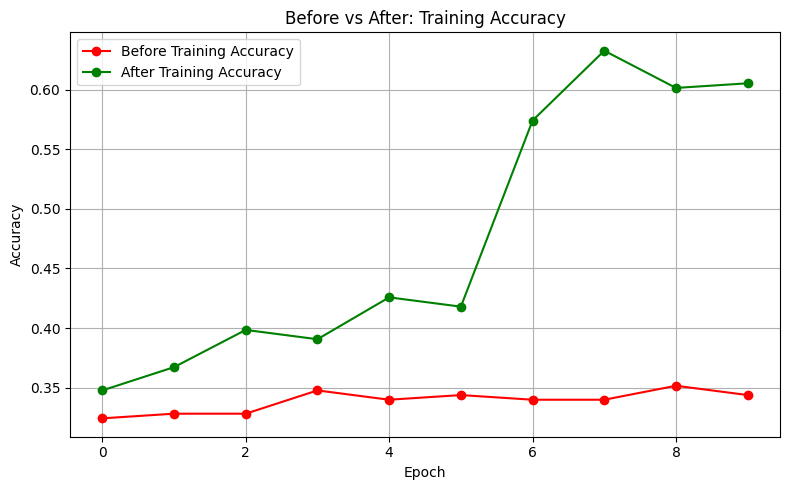

Saved to Google Drive: training_accuracy.png


In [75]:
plt.figure(figsize=(8, 5))
plt.plot(before_history.history['accuracy'], label='Before Training Accuracy', color='red',   marker='o')
plt.plot(after_history.history['accuracy'],  label='After Training Accuracy',  color='green', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Before vs After: Training Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/training_accuracy.png', dpi=150)
plt.show()
print('Saved to Google Drive: training_accuracy.png')

## Step 9: Plot Validation Accuracy

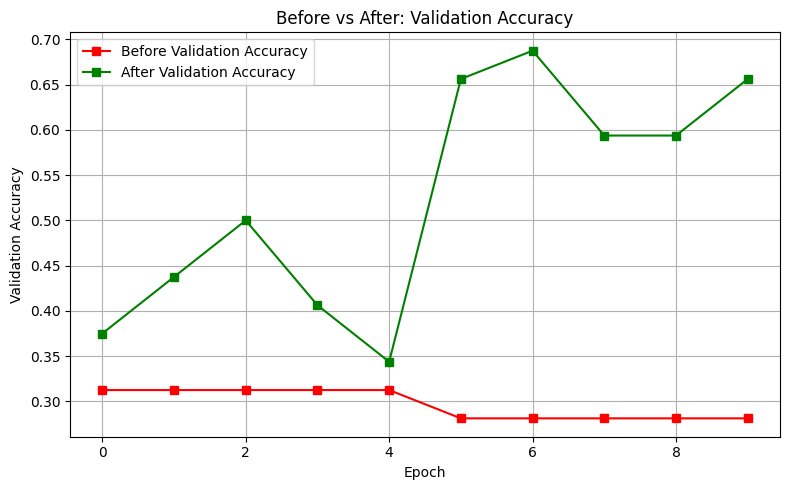

Saved to Google Drive: validation_accuracy.png


In [76]:
plt.figure(figsize=(8, 5))
plt.plot(before_history.history['val_accuracy'], label='Before Validation Accuracy', color='red',   marker='s')
plt.plot(after_history.history['val_accuracy'],  label='After Validation Accuracy',  color='green', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Before vs After: Validation Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/validation_accuracy.png', dpi=150)
plt.show()
print('Saved to Google Drive: validation_accuracy.png')

## Step 10: Plot Training Loss

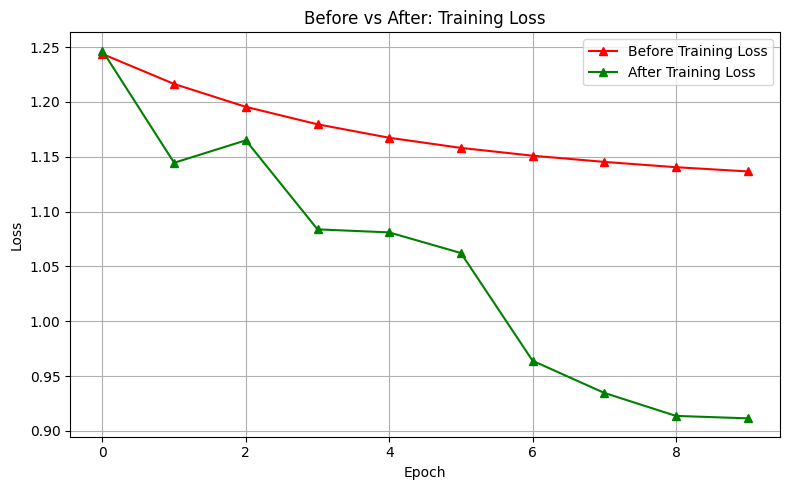

Saved to Google Drive: training_loss.png


In [77]:
plt.figure(figsize=(8, 5))
plt.plot(before_history.history['loss'], label='Before Training Loss', color='red',   marker='^')
plt.plot(after_history.history['loss'],  label='After Training Loss',  color='green', marker='^')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Before vs After: Training Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/training_loss.png', dpi=150)
plt.show()
print('Saved to Google Drive: training_loss.png')

---
## Step 11: Summary Table

In [78]:
before_final_train_acc = before_history.history['accuracy'][-1]
after_final_train_acc  = after_history.history['accuracy'][-1]
before_final_val_acc   = before_history.history['val_accuracy'][-1]
after_final_val_acc    = after_history.history['val_accuracy'][-1]
before_final_loss      = before_history.history['loss'][-1]
after_final_loss       = after_history.history['loss'][-1]

print('=' * 65)
print(f'{"Feature":<28} {"BEFORE Model":<18} {"AFTER Model"}')
print('=' * 65)
print(f'{"Optimizer":<28} {"SGD":<18} {"Adam"}')
print(f'{"Learning Rate":<28} {"0.0001":<18} {"0.001"}')
print(f'{"Number of Hidden Layers":<28} {"1 (16 neurons)":<18} {"2 (128→64 neurons)"}')
print(f'{"Final Training Accuracy":<28} {before_final_train_acc:.4f}{"":10} {after_final_train_acc:.4f}')
print(f'{"Final Validation Accuracy":<28} {before_final_val_acc:.4f}{"":10} {after_final_val_acc:.4f}')
print(f'{"Final Test Accuracy":<28} {before_test_acc:.4f}{"":10} {after_test_acc:.4f}')
print(f'{"Final Training Loss":<28} {before_final_loss:.4f}{"":10} {after_final_loss:.4f}')
print('=' * 65)

Feature                      BEFORE Model       AFTER Model
Optimizer                    SGD                Adam
Learning Rate                0.0001             0.001
Number of Hidden Layers      1 (16 neurons)     2 (128→64 neurons)
Final Training Accuracy      0.3438           0.6055
Final Validation Accuracy    0.2812           0.6562
Final Test Accuracy          0.5200           0.7200
Final Training Loss          1.1366           0.9115


## Assignment Questions

**Analyze the BEFORE Model:**
1. **Did the model learn fast or slow?**
The model learned very slowly. The accuracy increased marginally over 10 epochs, reaching 0.3438. The loss also decreased very slowly.
2. **Was the accuracy high or low?**
The accuracy was very low across the board. The final training accuracy was around 34.38%, validation accuracy was 28.12%, and test accuracy was 52.00%. These values are poor for a classification task with 3 classes.
3. **Did the loss decrease significantly?**
No, the loss decreased very slowly and remained high. It reduced to 1.1366 after 10 epochs, indicating minimal learning.
4. **What caused the weak performance?**
The weak performance was primarily caused by poor optimization choices: a very slow learning rate (0.0001) for the Stochastic Gradient Descent (SGD) optimizer, and a very shallow model architecture with only one hidden layer containing just 16 neurons. This combination limit the model's capacity to learn complex patterns and its speed of convergence

**Analyze the Graphs:**
1. **Which model learned faster?**
The AFTER model learned significantly faster, as evidenced by its rapid increase in accuracy and decrease in loss during training compared to the BEFORE model.
2. **Which model had lower loss?**
The AFTER model achieved a much lower loss. Its final training loss was 0.9115 and test loss was 0.9037, which are considerably better than the BEFORE model's final training loss (1.1366) and test loss (1.0795) respectively.
3. **Which model generalized better?**
The AFTER model generalized better. Its final validation accuracy (65.62%) and test accuracy (72.00%) were significantly higher than the BEFORE model's final validation accuracy (28.12%) and test accuracy (52.00%), indicating it performs well on unseen data and is not overfitting as severely.
4. **How did the optimizer affect performance?**
The change from SGD with a very small learning rate to Adam with a higher learning rate drastically improved performance. Adam is an adaptive optimizer that adjusts learning rates for each parameter, leading to faster convergence and often better overall performance compared to basic SGD, especially with appropriate learning rates.
5. **Why is validation accuracy important?**
Validation accuracy is crucial because it provides an unbiased estimate of the model's performance on unseen data during the training process. It helps detect overfitting (when the model performs well on training data but poorly on new data) and guides hyperparameter tuning without touching the final test set.
6. **Which graph shows better optimization?**
The graphs for the AFTER model (training accuracy, validation accuracy, and training loss) would clearly show better optimization. The accuracy curves for the AFTER model would rise steeply and reach higher values, while its loss curve would drop quickly and stabilize at a much lower point than the BEFORE model's curves.

**Reflection (3–5 sentences):**  
Optimization significantly improved the neural network performance in this comparison. The switch from a simple SGD optimizer with a very low learning rate to the more advanced Adam optimizer with a slightly higher learning rate enabled much faster and more effective learning. Additionally, increasing the model's complexity by adding a second dense layer and more neurons (from 16 to 128 then 64) allowed the model to capture more intricate patterns in the image data. These combined architectural and hyperparameter changes resulted in substantially higher accuracy and lower loss on both the training and validation sets, demonstrating that proper optimization is key to building an effective neural network.